In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#用 Pandas 讀取 CSV 檔案，存進變數 df（dataframe 的縮寫）
df = pd.read_csv('../data/insurance_policyholder_churn_synthetic.csv')
df.head()  # 顯示前 5 筆資料，快速確認資料載入是否正確

c:\Users\user\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,customer_id,as_of_date,region_name,age,age_band,marital_status,customer_tenure_months,multi_policy_flag,num_policies,policy_type,...,avg_settlement_time_days,days_since_last_claim,num_contacts_12m,complaint_flag,complaint_resolution_days,quote_requested_flag,coverage_downgrade_flag,churn_flag,churn_type,churn_probability_true
0,1,2025-12-31,Manawatu-Whanganui,24,18-24,Married,128,1,4,Auto,...,7,1616,0,0,0,0,0,0,No churn,0.048626
1,2,2025-12-31,Auckland,70,65-74,Married,76,1,3,Auto,...,15,1760,1,0,0,0,0,0,No churn,0.067888
2,3,2025-12-31,Bay of Plenty,62,55-64,Married,129,0,1,Auto,...,24,1581,1,0,0,0,0,0,No churn,0.223765
3,4,2025-12-31,Bay of Plenty,47,45-54,Single,104,0,1,Auto,...,17,1688,1,0,0,0,0,0,No churn,0.602455
4,5,2025-12-31,Bay of Plenty,47,45-54,Married,22,1,3,Life,...,24,1592,1,0,0,0,0,0,No churn,0.050723


In [2]:
print(df.shape)    # 回傳資料的維度：(列數（筆數）,欄數):(50000, 40)
df.info()    #欄位名稱+資料型態+非空值數量

(50000, 40)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  50000 non-null  int64  
 1   as_of_date                   50000 non-null  object 
 2   region_name                  50000 non-null  object 
 3   age                          50000 non-null  int64  
 4   age_band                     50000 non-null  object 
 5   marital_status               50000 non-null  object 
 6   customer_tenure_months       50000 non-null  int64  
 7   multi_policy_flag            50000 non-null  int64  
 8   num_policies                 50000 non-null  int64  
 9   policy_type                  50000 non-null  object 
 10  renewal_month                50000 non-null  int64  
 11  current_premium              50000 non-null  float64
 12  premium_last_year            50000 non-null  float64
 13  prem

In [3]:
print(df['churn_flag'].value_counts())                  #流失筆數
print(df['churn_flag'].value_counts(normalize = True))  #流失比率

churn_flag
0    34917
1    15083
Name: count, dtype: int64
churn_flag
0    0.69834
1    0.30166
Name: proportion, dtype: float64


In [4]:
df.describe()    #Pandas 內建的統計摘要函數

,customer_id,age,customer_tenure_months,multi_policy_flag,num_policies,renewal_month,current_premium,premium_last_year,premium_change_pct,num_price_increases_last_3y,...,payout_ratio_12m,avg_settlement_time_days,days_since_last_claim,num_contacts_12m,complaint_flag,complaint_resolution_days,quote_requested_flag,coverage_downgrade_flag,churn_flag,churn_probability_true
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,51.461700,90.36882,0.318640,1.638760,6.49762,1047.882399,994.319903,0.060795,1.669360,...,0.774165,18.17572,971.374400,1.285900,0.040440,0.493060,0.108480,0.098520,0.301660,0.303564
std,14433.901067,19.644405,51.83518,0.465954,1.041848,3.43503,455.932852,440.611049,0.080826,0.818957,...,0.039917,7.94916,501.320714,1.156213,0.196991,2.673779,0.310989,0.298019,0.458983,0.232942
min,1.000000,18.000000,1.00000,0.000000,1.000000,1.00000,120.000000,92.740000,-0.160200,0.000000,...,0.550000,1.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.018915
25%,12500.750000,34.000000,45.00000,0.000000,1.000000,4.00000,745.707500,701.577500,0.004600,1.000000,...,0.750000,13.00000,560.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.130210
50%,25000.500000,52.000000,90.00000,0.000000,1.000000,6.00000,1009.755000,954.720000,0.059800,2.000000,...,0.750000,18.00000,981.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.242322
75%,37500.250000,68.000000,135.00000,1.000000,2.000000,9.00000,1324.462500,1259.262500,0.116300,2.000000,...,0.800000,24.00000,1402.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.414728
max,50000.000000,85.000000,180.00000,1.000000,4.000000,12.00000,3348.350000,3374.460000,0.410500,3.000000,...,0.850000,53.00000,1824.000000,10.000000,1.000000,31.000000,1.000000,1.000000,1.000000,1.000000


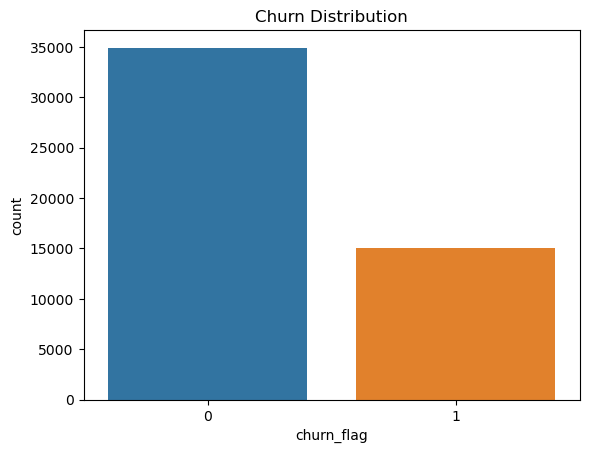

In [5]:
sns.countplot(x='churn_flag', data = df)  #Seaborn 的長條圖函數，用來計算每個類別出現幾次
plt.title('Churn Distribution')
plt.show()

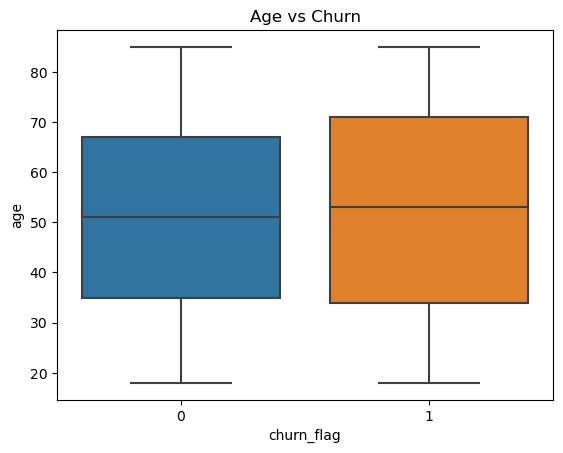

In [6]:
# Seaborn 的箱型圖函數，用來比較兩組的數值分佈
sns.boxplot(x='churn_flag', y='age', data=df)  
plt.title('Age vs Churn')
plt.show()

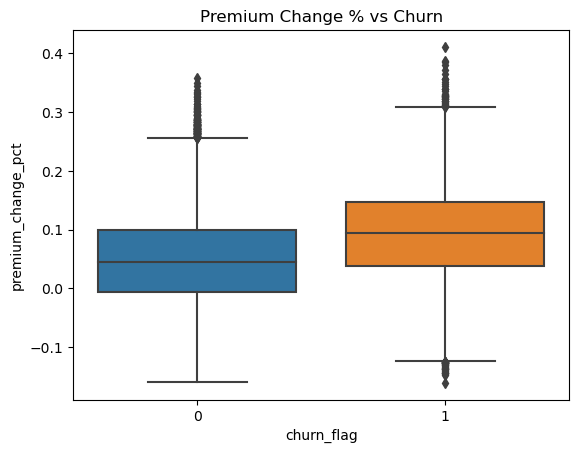

In [7]:
sns.boxplot(x='churn_flag', y='premium_change_pct', data=df)
plt.title('Premium Change % vs Churn')
plt.show()

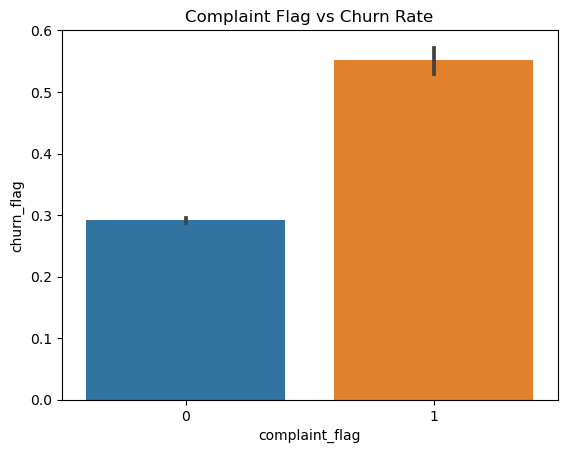

In [8]:
#長條圖，用來顯示某個類別對應的數值平均
sns.barplot(x='complaint_flag', y='churn_flag', data=df)
plt.title('Complaint Flag vs Churn Rate')
plt.show()

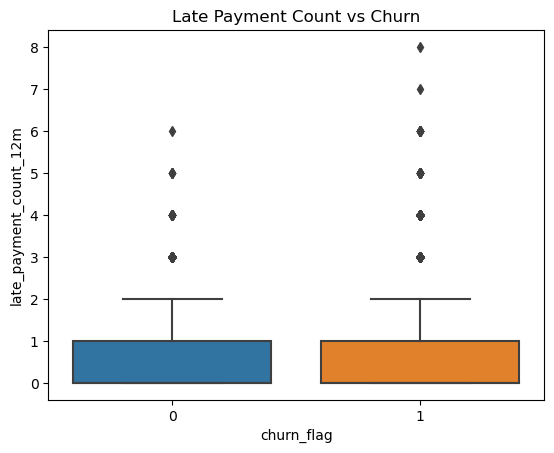

In [11]:
sns.boxplot(x='churn_flag', y='late_payment_count_12m',data=df)  #延遲付款次數
plt.title('Late Payment Count vs Churn')
plt.show()

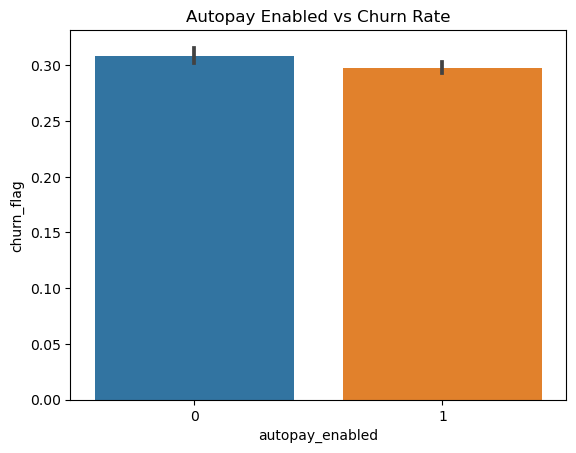

In [12]:
sns.barplot(x='autopay_enabled', y='churn_flag', data=df)
plt.title('Autopay Enabled vs Churn Rate')
plt.show()

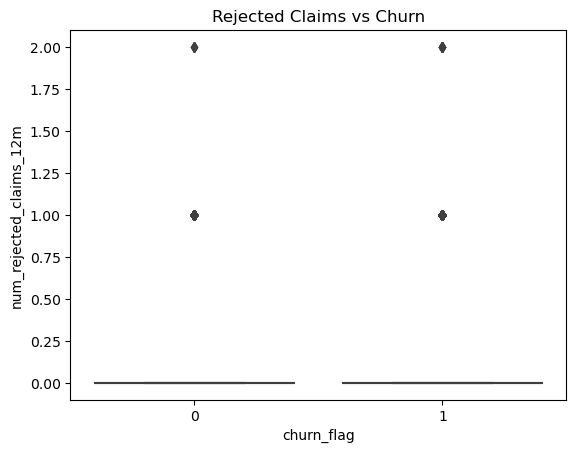

In [14]:
sns.boxplot(x='churn_flag', y='num_rejected_claims_12m', data=df)  #被拒絕理賠
plt.title('Rejected Claims vs Churn')
plt.show()

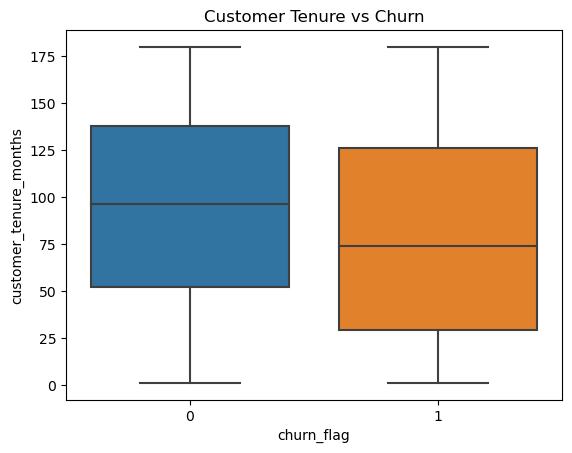

In [ ]:
sns.boxplot(x='churn_flag', y='customer_tenure_months', data=df) #客戶投保年資
plt.title('Customer Tenure vs Churn')
plt.show()

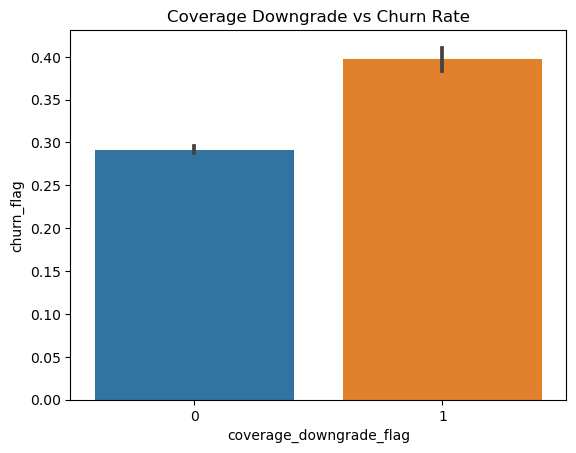

In [ ]:
sns.barplot(x='coverage_downgrade_flag', y='churn_flag', data=df)  #主動降低保障的客戶
plt.title('Coverage Downgrade vs Churn Rate')
plt.show()